# Trabajo Práctico 2 - Problema 1: Diagnóstico de Cáncer de Mama

## Introducción

Este notebook aborda el problema de clasificación binaria para el diagnóstico de tumores mamarios (benignos vs malignos) utilizando regresión logística implementada desde cero.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src/')
from preprocessing import *
from metrics import *
from models import *
from utils import *
from balanced import *

## 1. Carga y Exploración de Datos

In [ ]:
from IPython.display import Markdown, display

balanced_dev = pd.read_csv('../data1/cell_diagnosis_dev.csv')
balanced_test = pd.read_csv('../data1/cell_diagnosis_test.csv')

### Datos Balanceados (Desarrollo)

**Forma del dataset**: (1663, 15)

**Primeras filas del dataset**:

,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis,CellType,GeneticMutation
0,63.423148,0.500594,1.473261,23.300222,NaN,0.477657,3.434832,2.492852,-10.000000,78.625935,5.727217,41.158399,0.0,Epthlial,Absnt
1,72.906362,0.474808,1.361360,21.336137,29.856233,0.481035,2.702433,2.281137,63.084699,NaN,5.319552,NaN,1.0,Epthlial,Presnt
2,70.711969,0.481701,NaN,21.521406,30.582427,0.472651,2.786606,2.318029,61.347022,NaN,NaN,NaN,1.0,???,Absnt
3,73.210206,NaN,1.427612,22.437077,29.887970,0.439511,2.998380,2.149232,64.047169,80.693058,NaN,37.843069,1.0,Mesnchymal,Presnt
4,68.348288,NaN,1.454116,21.150723,28.328197,NaN,2.987601,NaN,62.197197,81.737990,4.347438,43.444881,1.0,Epthlial,Presnt


**Información del dataset**:

...

None

**Estadísticas descriptivas**:

,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis
count,1333.000000,1347.000000,1362.000000,1366.000000,1347.000000,1369.000000,1343.000000,1343.000000,1359.000000,1375.000000,1347.000000,1358.000000,1663.000000
mean,83.247087,0.598657,2.097344,26.094973,33.989815,0.548800,5.326484,2.825365,74.126375,93.199374,5.968017,47.725954,0.450391
std,100.316719,0.565438,4.987573,24.842157,32.809627,0.612232,11.572456,2.697956,77.819461,82.574244,5.649530,44.133737,0.497683
min,-100.000000,-1.413038,-3.000000,10.000000,5.000000,-4.461755,-50.000000,-3.438990,-50.000000,-10.000000,-0.997057,0.000000,0.000000
25%,66.572149,0.479758,1.397010,21.279126,26.304514,0.456400,2.776731,2.254502,58.170436,79.130570,4.782475,37.513981,0.000000
50%,69.704323,0.498832,1.445035,22.066810,28.448318,0.474836,3.080247,2.414464,60.993969,79.987328,5.068099,40.859154,0.000000
75%,72.653147,0.523018,1.485651,22.823319,30.506774,0.494613,3.423066,2.534339,63.041642,80.986905,5.346464,43.913527,1.000000
max,1000.000000,5.048566,50.000000,263.793425,299.350559,5.029925,100.000000,24.871762,563.622684,807.181058,54.512433,440.902261,1.000000


**Distribución de clases**:

Diagnosis
0.0    0.549609
1.0    0.450391
Name: proportion, dtype: float64

In [ ]:
def show_basic_info(df, name):
    display(Markdown(f"### {name}"))
    display(Markdown(f"**Forma del dataset**: {df.shape}"))
    display(Markdown("**Primeras filas del dataset**:"))
    display(df.head())
    display(Markdown("**Información del dataset**:"))
    display(df.info())
    display(Markdown("**Estadísticas descriptivas**:"))
    display(df.describe())
    display(Markdown("**Distribución de clases**:"))
    display(df['Diagnosis'].value_counts(normalize=True))

# show_basic_info(balanced_dev, "Datos Balanceados (Desarrollo)")

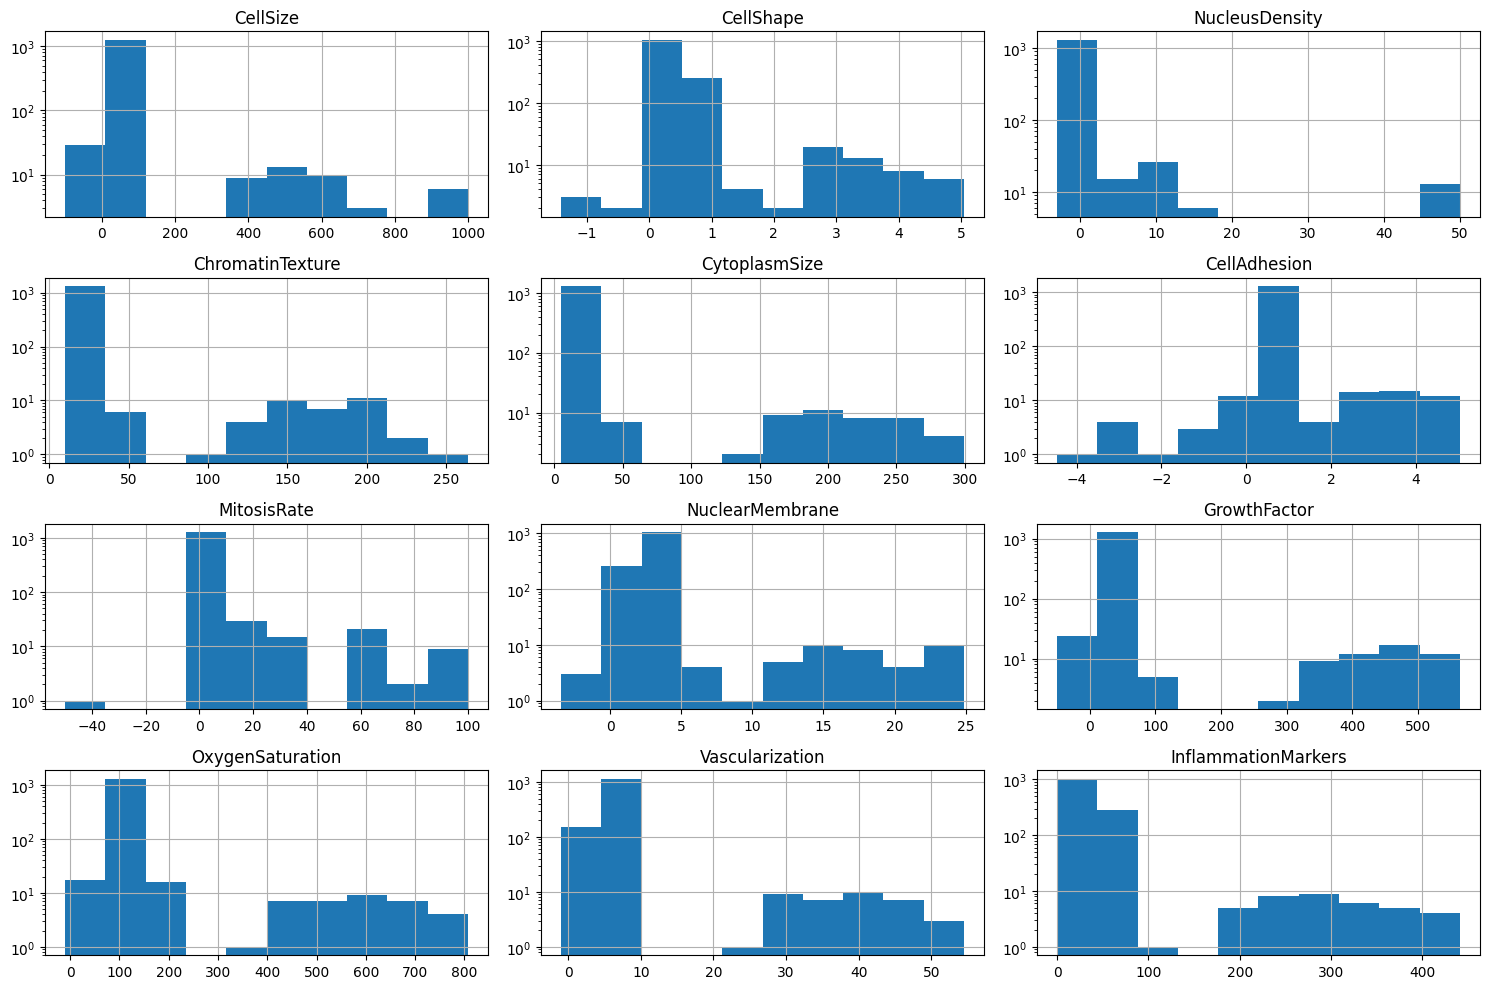

In [ ]:
# balanced_dev.drop(columns=["Diagnosis"]).hist(figsize=(15, 10), log=True)
# plt.tight_layout()
# plt.show()

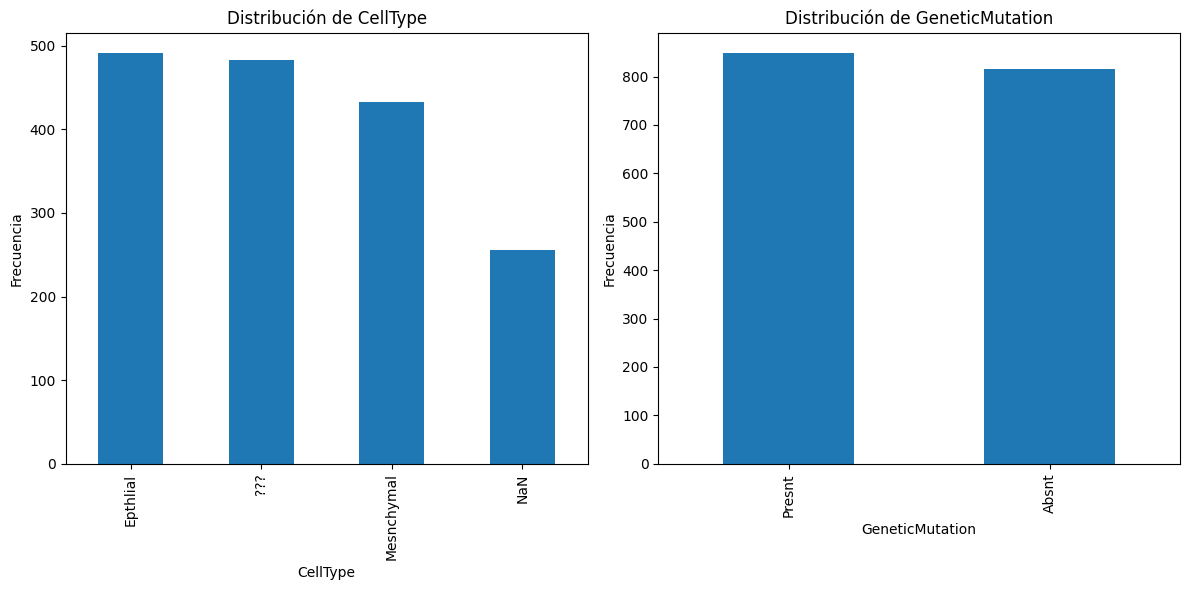

In [ ]:
# categorical_columns = ["CellType", "GeneticMutation"]
# fig, axes = plt.subplots(nrows=1, ncols=len(categorical_columns), figsize=(12, 6))

# for i, col in enumerate(categorical_columns):
#     value_counts = balanced_dev[col].value_counts(dropna=False)
#     value_counts.index = value_counts.index.fillna('NaN')
#     value_counts.plot(kind="bar", ax=axes[i])
#     axes[i].set_title(f"Distribución de {col}")
#     axes[i].set_xlabel(col)
#     axes[i].set_ylabel("Frecuencia")

# plt.tight_layout()
# plt.show()

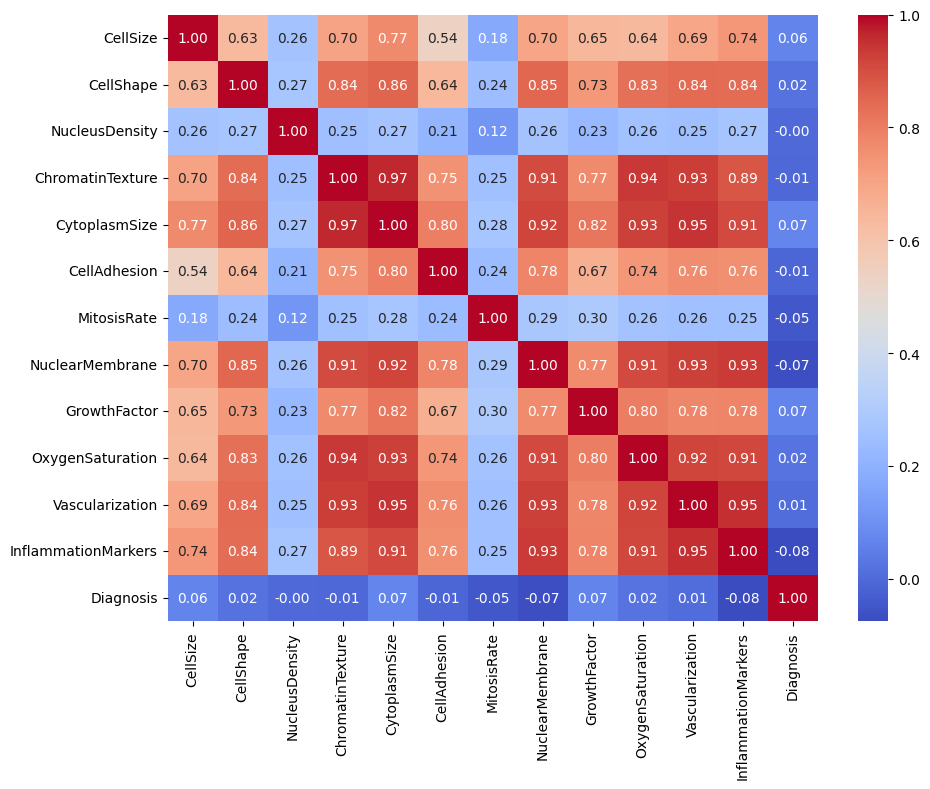

In [ ]:
# numeric_df = balanced_dev.select_dtypes(include=[np.number]) 
# corr = numeric_df.corr()

# fig, axes = plt.subplots(1, 1, figsize=(10, 8))
# sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axes)
# plt.tight_layout()
# plt.show()

In [14]:
norm = handle_categorical_features(balanced_dev)
clustered_df = norm.copy()
norm, _, _ = normalize(norm)
norm = handle_missing_values(norm)
labels, centroids_df = Kmeans(norm.drop(columns=["Diagnosis"]), n_clusters=2)
clustered_df['Cluster'] = labels

In [15]:
cluster_0 = clustered_df[clustered_df['Cluster'] == 0]
cluster_1 = clustered_df[clustered_df['Cluster'] == 1]
cluster_0 = handle_missing_values(cluster_0)
cluster_0 = clean_data(cluster_0)
cluster_1 = handle_missing_values(cluster_1)
cluster_1 = clean_data(cluster_1)

In [ ]:
numeric_columns = cluster_0.select_dtypes(include=[np.number]).columns
sns.pairplot(cluster_0[numeric_columns], hue="Diagnosis", diag_kind="kde", markers=["o", "s"])
plt.suptitle("Pairplot de variables numéricas (Cluster 0)", y=1.02)
plt.show()

sns.pairplot(cluster_1[numeric_columns], hue="Diagnosis", diag_kind="kde", markers=["o", "s"])
plt.suptitle("Pairplot de variables numéricas (Cluster 1)", y=1.02)
plt.show()

In [ ]:
sns.pairplot(pd.concat([cluster_0, cluster_1])[numeric_columns], hue="Cluster", diag_kind="kde", markers=["o", "s"])
plt.suptitle("Pairplot de variables numéricas", y=1.02)
plt.show()

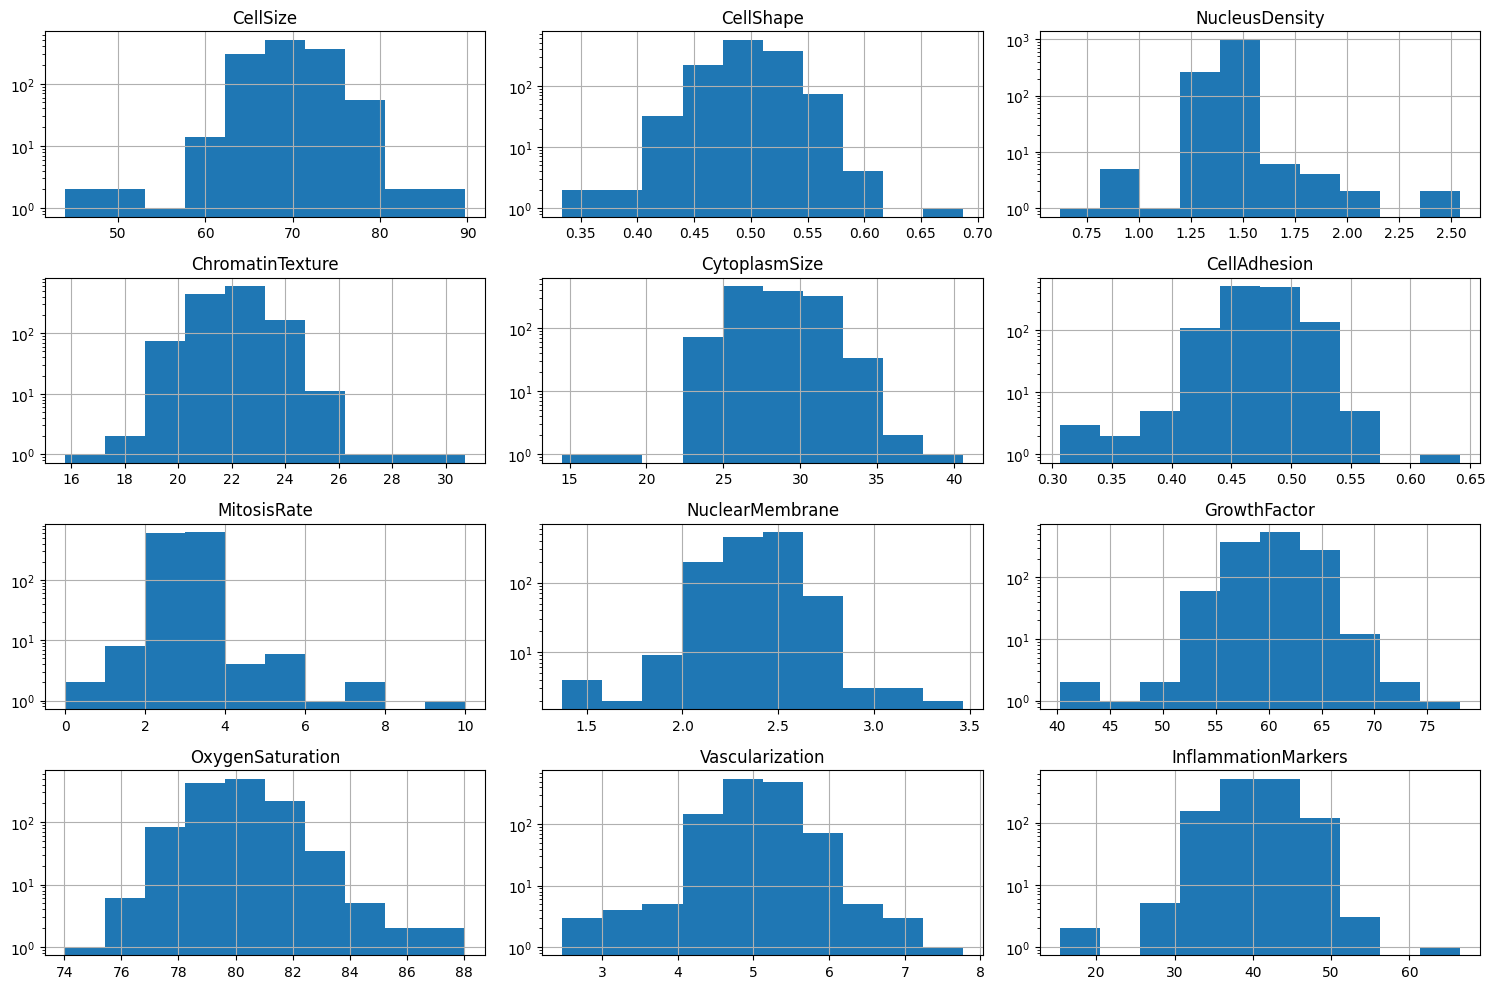

In [ ]:
clean_df = clean_data(balanced_dev)
clean_df.drop(columns=["Diagnosis"]).hist(figsize=(15, 10), log=True)
plt.tight_layout()
plt.show()

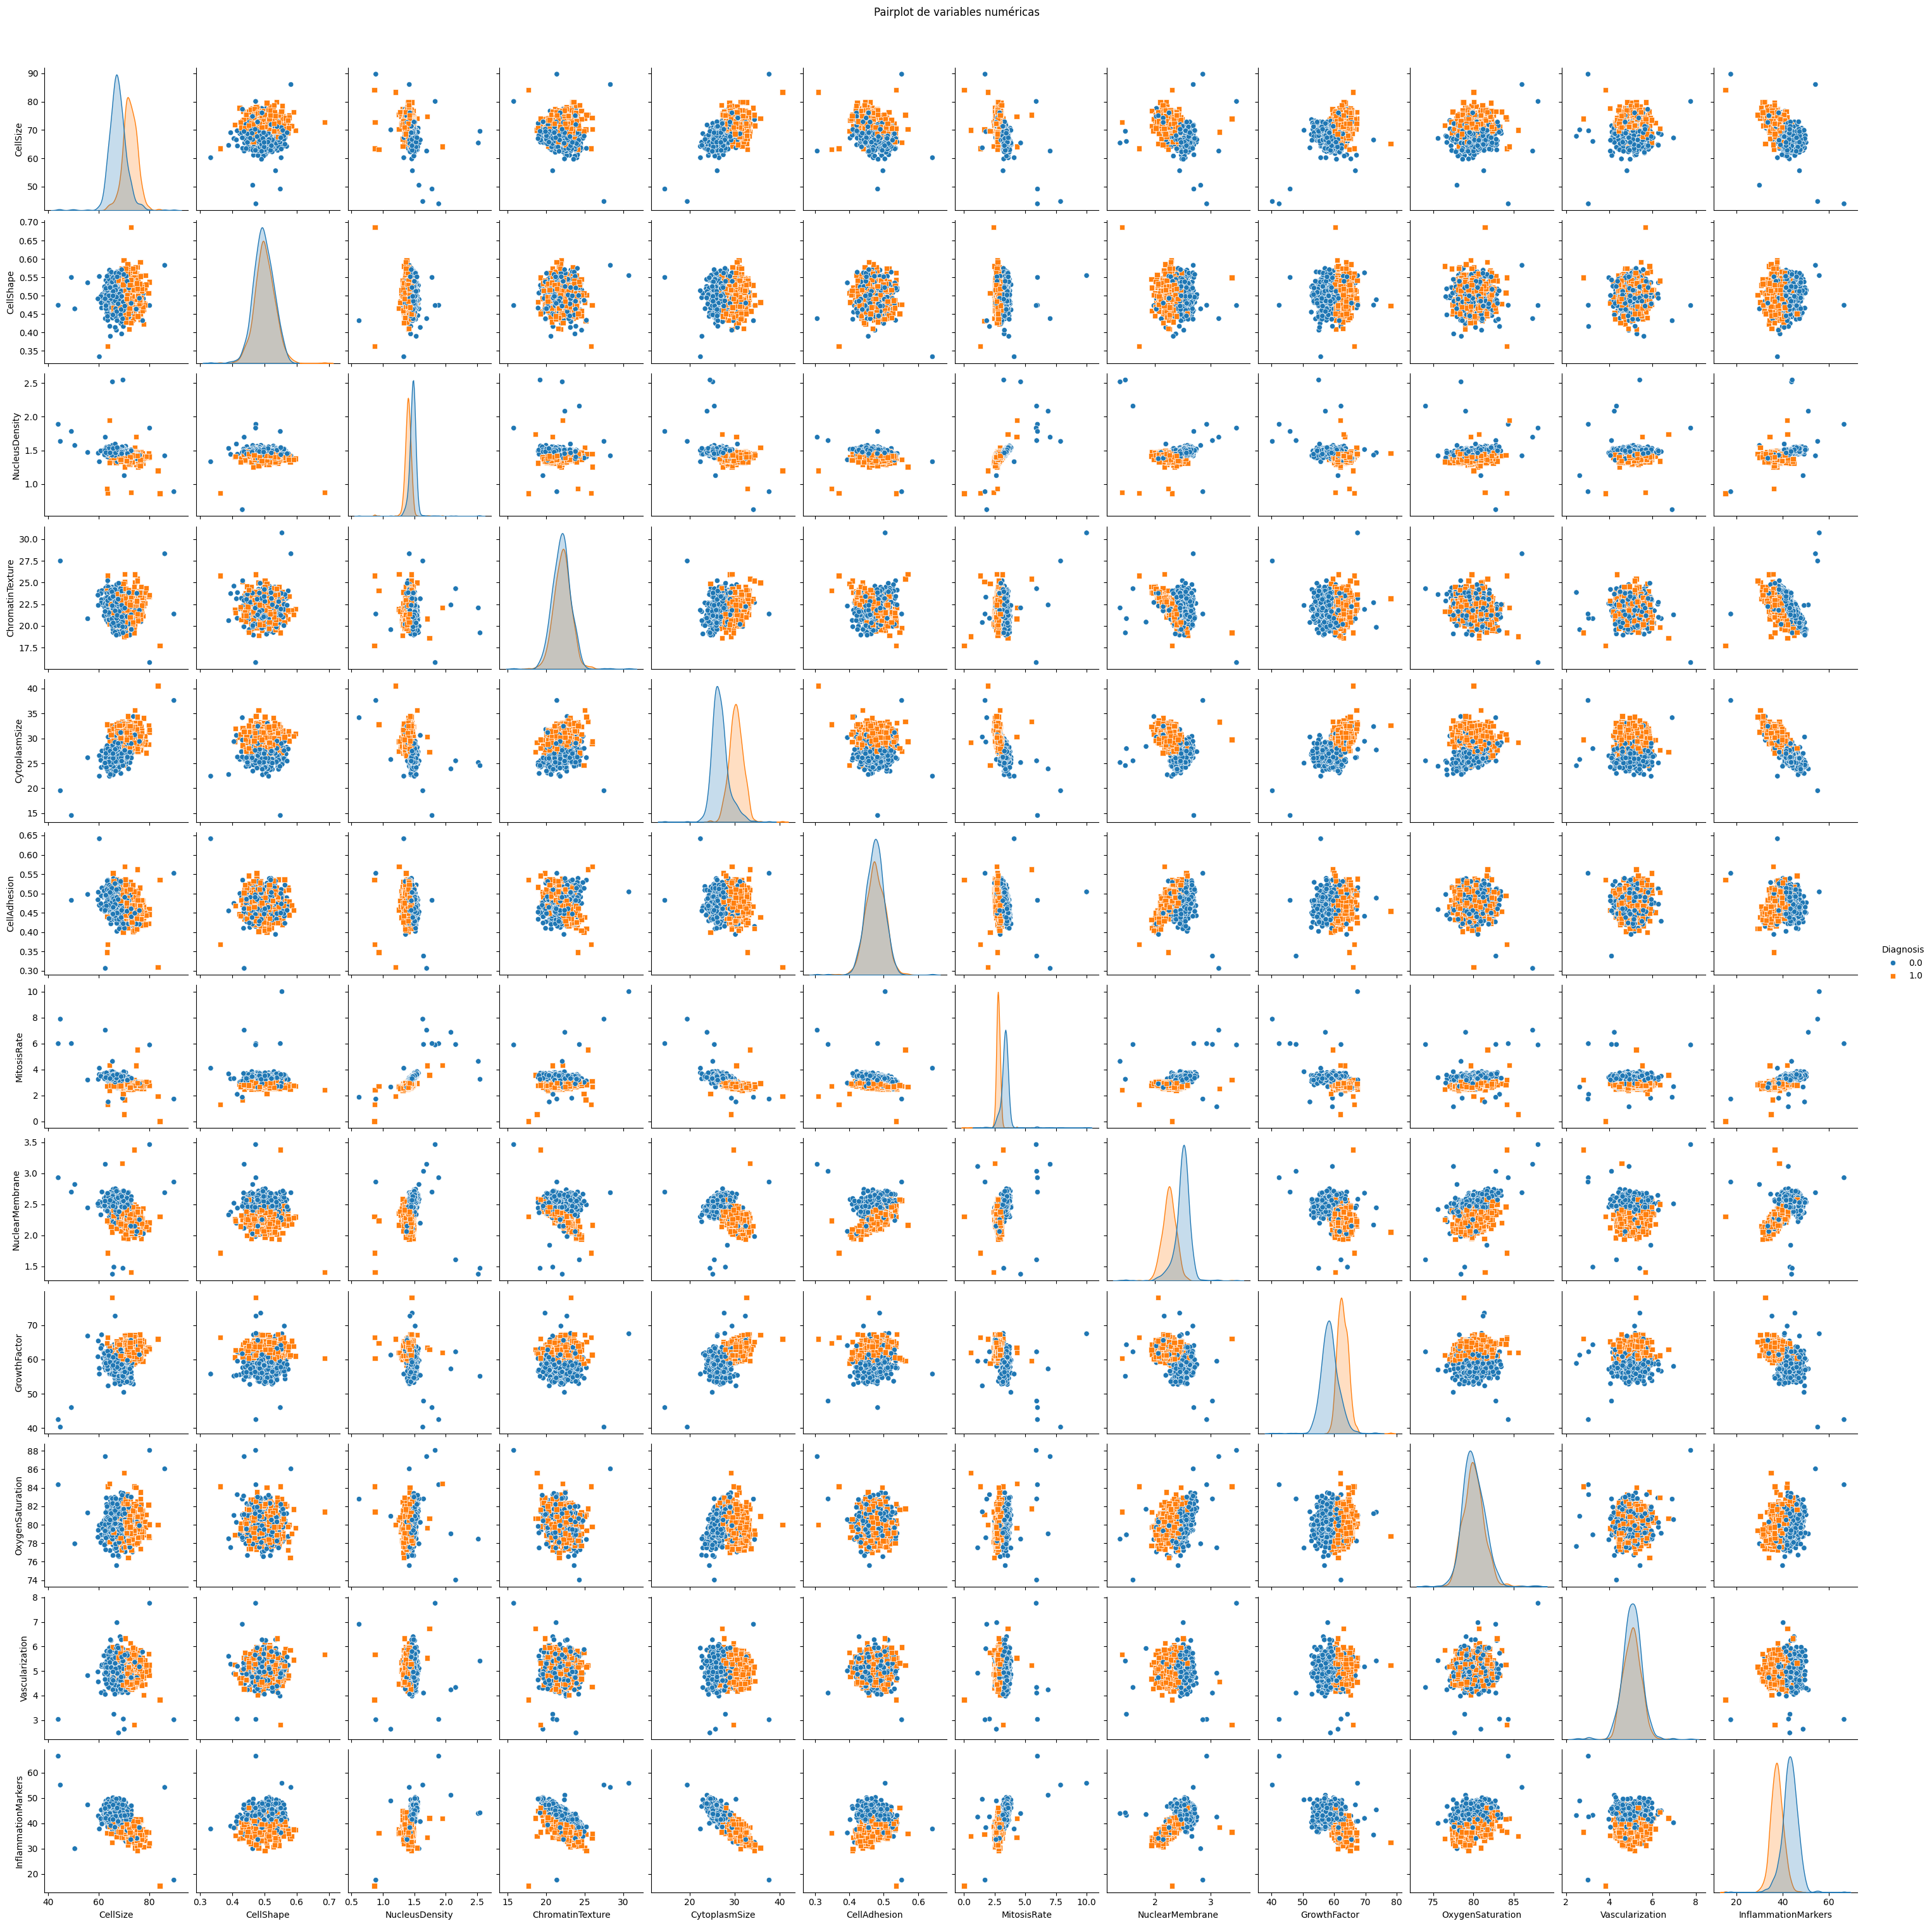

In [ ]:
sns.pairplot(clean_df, hue="Diagnosis", diag_kind="kde", markers=["o", "s"])
plt.suptitle("Pairplot de variables numéricas", y=1.02)
plt.show()

In [ ]:
clean_df = handle_categorical_features(clean_df)

## 2. Preprocesamiento de Datos

In [ ]:
X_train, X_val, y_train, y_val, means, stds = split_and_normalize(clean_df, target_column='Diagnosis', exclude_cols=["Epthlial", "Mesnchymal", "GeneticMutation"])

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)


Accuracy: 0.80
Precision: 0.82
Recall: 0.70
F1-Score: 0.75

AUC-PR: 0.79
AUC-ROC: 0.84


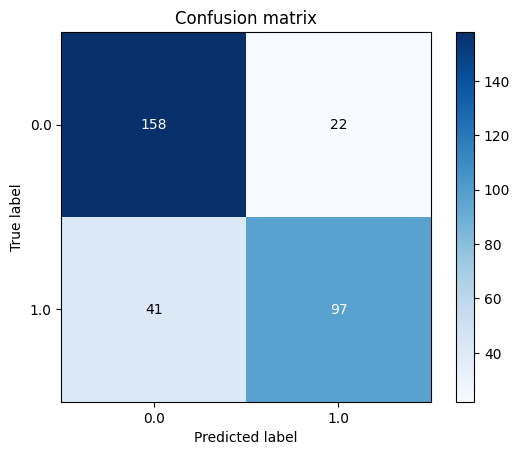

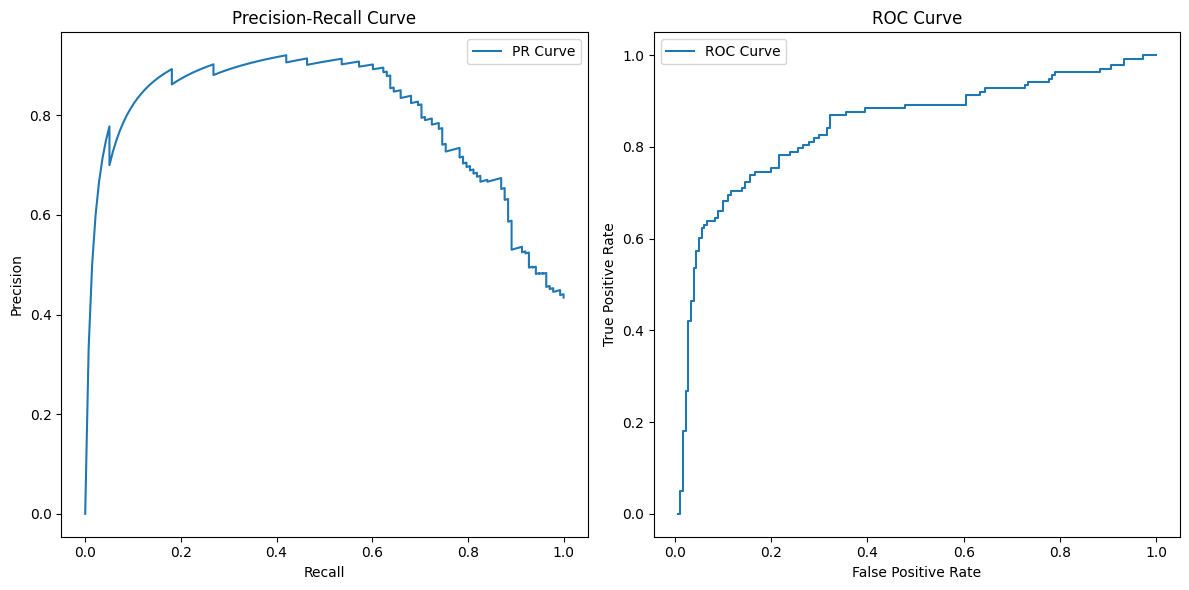

In [ ]:
display_full_metrics(y_val, y_pred, y_pred_proba)

## 3. Optimización de Hiperparámetros

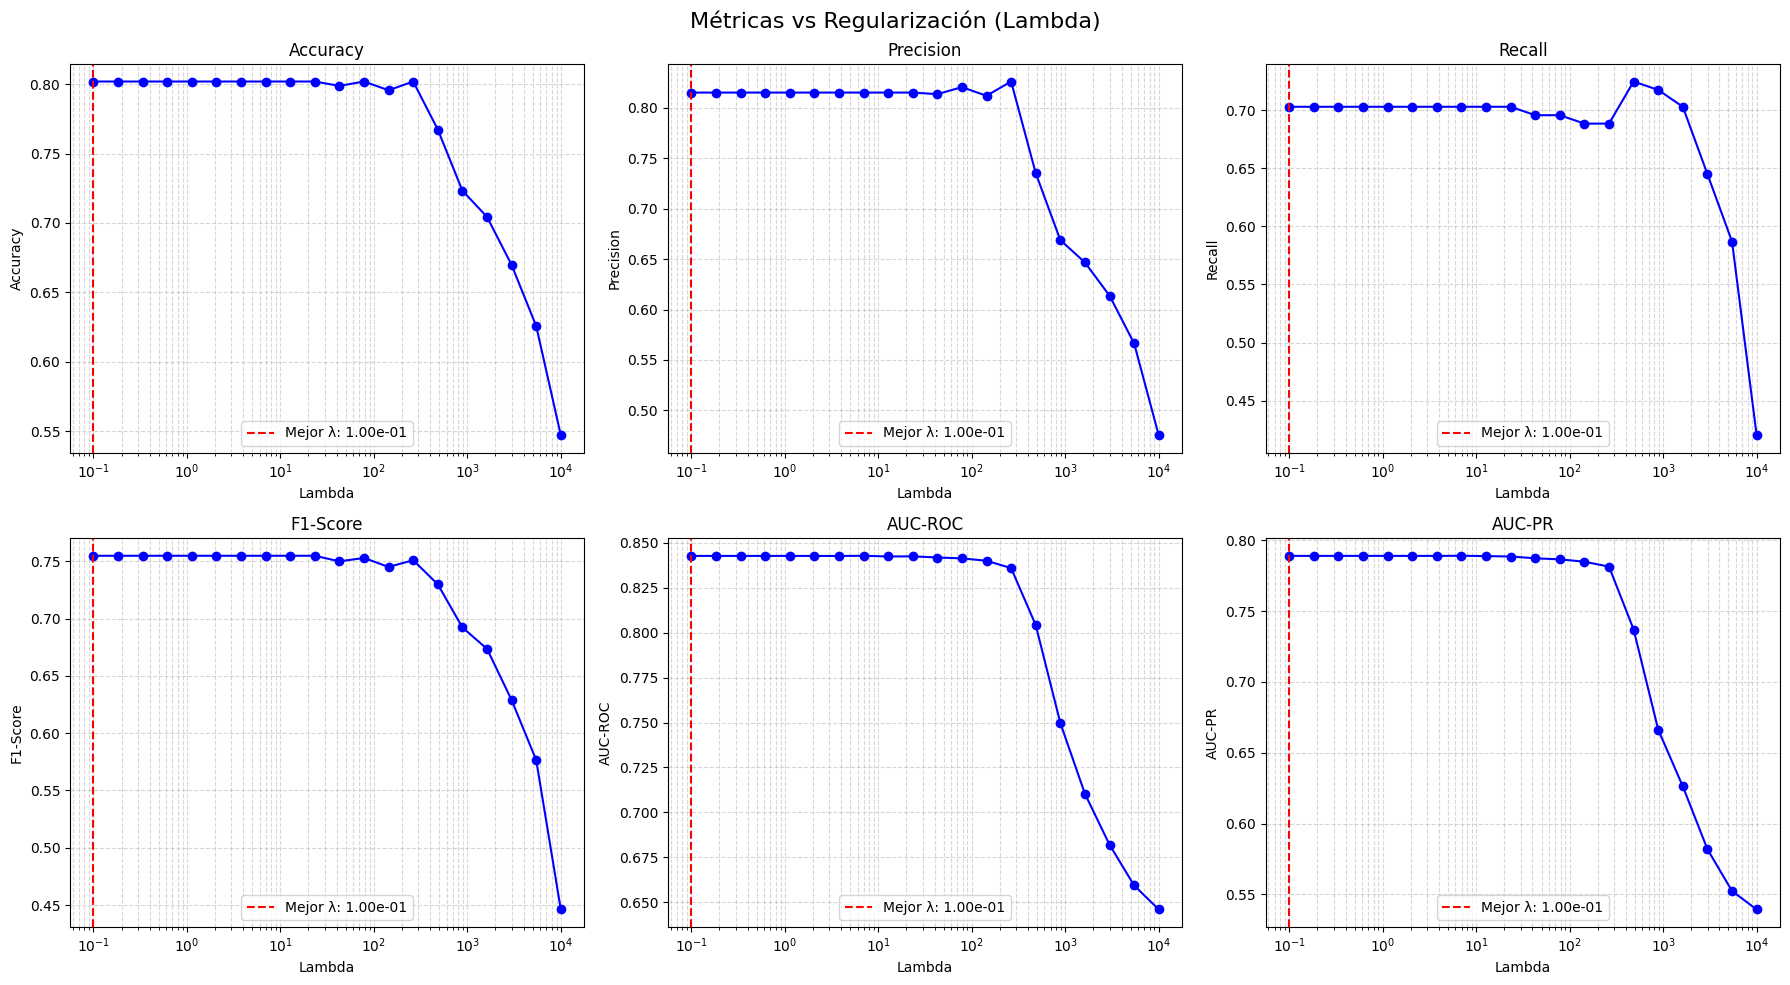


Mejor λ: 1.00e-01 con F1-Score: 0.7549


In [ ]:
# Configurar más valores lambda y en escala logarítmica
lambda_values = np.logspace(-1, 4, num=20)  # Más puntos intermedios

# Lista para almacenar todas las métricas
all_metrics = []
best_f1 = -1
best_lambda = None

for lambda_ in lambda_values:
    # Entrenar y evaluar modelo
    model = LogisticRegression(lambda_=lambda_)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)
    
    # Calcular y almacenar métricas
    metrics = calculate_metrics(y_val, y_pred, y_pred_proba)
    metrics['lambda'] = lambda_
    all_metrics.append(metrics)
    
    # Actualizar mejor modelo
    if metrics['f1_score'] > best_f1:
        best_f1 = metrics['f1_score']
        best_lambda = lambda_

# Extraer métricas para graficar
lambdas = [m['lambda'] for m in all_metrics]
accuracy = [m['accuracy'] for m in all_metrics]
precision = [m['precision'] for m in all_metrics]
recall = [m['recall'] for m in all_metrics]
f1_scores = [m['f1_score'] for m in all_metrics]
auc_roc = [m['auc_roc'] for m in all_metrics]
auc_pr = [m['auc_pr'] for m in all_metrics]

# Configurar subplots
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Métricas vs Regularización (Lambda)', fontsize=16)

# Graficar cada métrica
metrics_to_plot = [
    ('Accuracy', accuracy),
    ('Precision', precision),
    ('Recall', recall),
    ('F1-Score', f1_scores),
    ('AUC-ROC', auc_roc),
    ('AUC-PR', auc_pr)
]

for i, (title, data) in enumerate(metrics_to_plot):
    ax = axs[i//3, i%3]
    ax.semilogx(lambdas, data, 'b-', marker='o')
    ax.axvline(best_lambda, color='r', linestyle='--', 
              label=f'Mejor λ: {best_lambda:.2e}')
    ax.set_title(title)
    ax.set_xlabel('Lambda')
    ax.set_ylabel(title)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

print(f"\nMejor λ: {best_lambda:.2e} con F1-Score: {best_f1:.4f}")

In [ ]:
best_model = LogisticRegression(lambda_=best_lambda)
df, means, stds = normalize(clean_df, exclude_cols=["Epthlial", "Mesnchymal", "GeneticMutation", "Diagnosis"])
df = handle_missing_values(df, strategy='knn', k=5)
best_model.fit( df.drop(columns=["Diagnosis"]), df["Diagnosis"])
save_model(best_model, "../modelos/best_model.pkl")

In [ ]:
balanced_test = handle_categorical_features(balanced_test)
test_set , _,_ = normalize(balanced_test, means, stds, exclude_cols=["Epthlial", "Mesnchymal", "GeneticMutation", "Diagnosis"])
test_set = handle_missing_values(test_set, strategy='knn', train_df=df, k=5)


Accuracy: 0.88
Precision: 0.86
Recall: 0.88
F1-Score: 0.87

AUC-PR: 0.69
AUC-ROC: 0.84


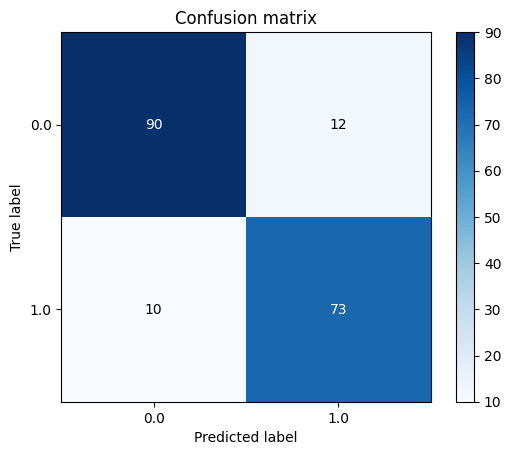

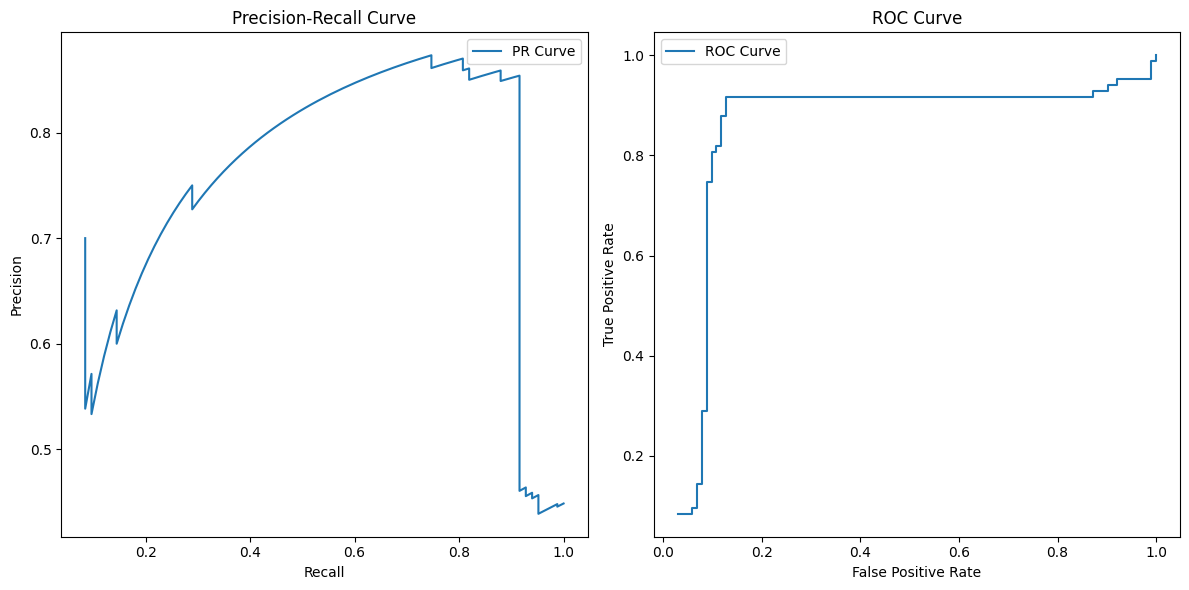

In [ ]:
y_test_pred = best_model.predict(test_set.drop(columns=["Diagnosis"]))
y_test_pred_proba = best_model.predict_proba(test_set.drop(columns=["Diagnosis"]))
display_full_metrics(balanced_test["Diagnosis"], y_test_pred, y_test_pred_proba)

## 4. Evaluación del Modelo con Datos Desbalanceados

In [ ]:
imbalanced_dev = pd.read_csv('../data1/cell_diagnosis_dev_imbalanced.csv')
imbalanced_test = pd.read_csv('../data1/cell_diagnosis_test_imbalanced.csv')

show_basic_info(imbalanced_dev, "Datos Desbalanceados (Desarrollo)")

### Datos Desbalanceados (Desarrollo)

**Forma del dataset**: (1218, 15)

**Información del dataset**:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CellSize             982 non-null    float64
 1   CellShape            981 non-null    float64
 2   NucleusDensity       998 non-null    float64
 3   ChromatinTexture     1006 non-null   float64
 4   CytoplasmSize        973 non-null    float64
 5   CellAdhesion         1004 non-null   float64
 6   MitosisRate          978 non-null    float64
 7   NuclearMembrane      993 non-null    float64
 8   GrowthFactor         988 non-null    float64
 9   OxygenSaturation     998 non-null    float64
 10  Vascularization      988 non-null    float64
 11  InflammationMarkers  999 non-null    float64
 12  Diagnosis            1218 non-null   float64
 13  CellType             1034 non-null   object 
 14  GeneticMutation      1218 non-null   object 
dtypes: float64(13), object(2)
memory usage

None

**Estadísticas descriptivas**:

,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis
count,982.000000,981.000000,998.000000,1006.000000,973.000000,1004.000000,978.000000,993.000000,988.000000,998.000000,988.000000,999.000000,1218.000000
mean,79.555996,0.598320,2.119365,26.175980,33.082141,0.554118,5.717573,2.896795,72.221366,93.240958,5.920371,49.316550,0.249589
std,89.853115,0.580204,4.879884,24.336051,32.333310,0.641056,11.985762,2.831194,76.313241,81.907593,5.486086,46.078477,0.432953
min,-100.000000,-1.413038,-3.000000,15.776662,5.000000,-4.461755,-5.000000,-3.438990,-50.000000,-10.000000,-0.997057,0.000000,0.000000
25%,65.969773,0.477829,1.416244,21.264939,25.907336,0.456123,2.890828,2.324643,57.325664,79.116121,4.781688,38.916909,0.000000
50%,68.331328,0.497931,1.463350,22.051707,27.252767,0.475207,3.296181,2.472245,59.536450,79.940819,5.074992,42.224414,0.000000
75%,71.488821,0.522337,1.495688,22.809761,29.639382,0.493890,3.470776,2.553760,62.259275,81.019424,5.359340,44.761177,0.000000
max,1000.000000,4.912125,50.000000,228.929540,299.350559,5.029925,100.000000,24.871762,563.622684,758.487171,54.512433,440.902261,1.000000


**Distribución de clases**:

Diagnosis
0.0    0.750411
1.0    0.249589
Name: proportion, dtype: float64

In [ ]:
imbalanced_dev = handle_categorical_features(imbalanced_dev)
imbalanced_dev = clean_data(imbalanced_dev)
imbalanced_dev.describe()

,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis,GeneticMutation,Epthlial,Mesnchymal
count,912.000000,914.000000,922.000000,956.000000,918.000000,938.000000,906.000000,933.000000,910.000000,927.000000,937.000000,948.000000,1154.000000,1154.000000,990.000000,990.000000
mean,68.643446,0.498518,1.457175,22.003484,27.661709,0.474364,3.208689,2.430566,59.653133,79.993679,5.051841,41.695780,0.251300,0.519064,0.352525,0.297980
std,3.990946,0.033746,0.107939,1.177983,2.382071,0.028319,0.524802,0.180488,3.227638,1.348061,0.450858,4.060264,0.433949,0.499853,0.477998,0.457602
min,43.918997,0.334014,0.621261,15.776662,14.542705,0.291218,1.116176,1.373884,40.316039,74.024381,2.475598,17.640453,0.000000,0.000000,0.000000,0.000000
25%,66.144756,0.477465,1.416244,21.234714,25.908045,0.456570,2.873119,2.321252,57.389635,79.114186,4.777379,38.809388,0.000000,0.000000,0.000000,0.000000
50%,68.331328,0.496945,1.461416,22.006395,27.186905,0.474387,3.272900,2.466415,59.491282,79.892678,5.059710,42.138831,0.000000,1.000000,0.000000,0.000000
75%,71.118995,0.518645,1.491195,22.710427,29.415848,0.492454,3.434862,2.545347,62.009233,80.804353,5.328268,44.507820,1.000000,1.000000,1.000000,1.000000
max,89.723070,0.773923,2.672229,30.726471,37.614354,0.641589,10.000000,3.461798,73.503334,88.044102,7.763249,66.466276,1.000000,1.000000,1.000000,1.000000


In [ ]:
X_train, X_val, y_train, y_val, means, stds = stratified_split_and_normalize(imbalanced_dev, target_column='Diagnosis', exclude_cols=["Epthlial", "Mesnchymal", "GeneticMutation"])

In [ ]:
strategies = {
    'Sin rebalanceo': (X_train, y_train),
    'Undersampling': random_undersample(X_train, y_train),
    'Oversampling duplicate': duplicate_oversample(X_train, y_train),
    'Oversampling SMOTE': SMOTE(X_train, y_train),
    'Cost re-weighting': (X_train, y_train)
}

n_class_0 = np.sum(y_train == 0)
n_class_1 = np.sum(y_train == 1)
class_weights = {
    0: n_class_1/n_class_0,
    1: 1.0           
}

results = {}

for strategy, (X_res, y_res) in strategies.items():
    if strategy == 'Cost re-weighting':
        model = LogisticRegression(lambda_=best_lambda, class_weight=class_weights)
    else:
        model = LogisticRegression(lambda_=best_lambda)

    model.fit(X_res, y_res)
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    metrics = calculate_metrics(y_val, y_pred, y_proba)
    results[strategy] = metrics

print("\n=== Tabla de Resultados ===")
print("{:<25} {:<10} {:<10} {:<10} {:<10} {:<10} {:<10}".format(
    "Modelo", "Accuracy", "Precision", "Recall", "F-Score", "AUC-ROC", "AUC-PR"))

for strategy in ['Sin rebalanceo', 'Undersampling', 'Oversampling duplicate', 
                'Oversampling SMOTE', 'Cost re-weighting']:
    m = results[strategy]
    print("{:<25} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f}".format(
        strategy, m['accuracy'], m['precision'], m['recall'], 
        m['f1_score'], m['auc_roc'], m['auc_pr']))


=== Tabla de Resultados ===
Modelo                    Accuracy   Precision  Recall     F-Score    AUC-ROC    AUC-PR    
Sin rebalanceo            0.8411     0.7500     0.5536     0.6370     0.8266     0.5870    
Undersampling             0.4876     0.2316     0.4464     0.3050     0.4675     0.2352    
Oversampling duplicate    0.6259     0.3004     0.3648     0.3295     0.5682     0.2839    
Oversampling SMOTE        0.7611     0.5178     0.7511     0.6130     0.8264     0.5874    
Cost re-weighting         0.7654     0.5377     0.4893     0.5124     0.7759     0.4752    


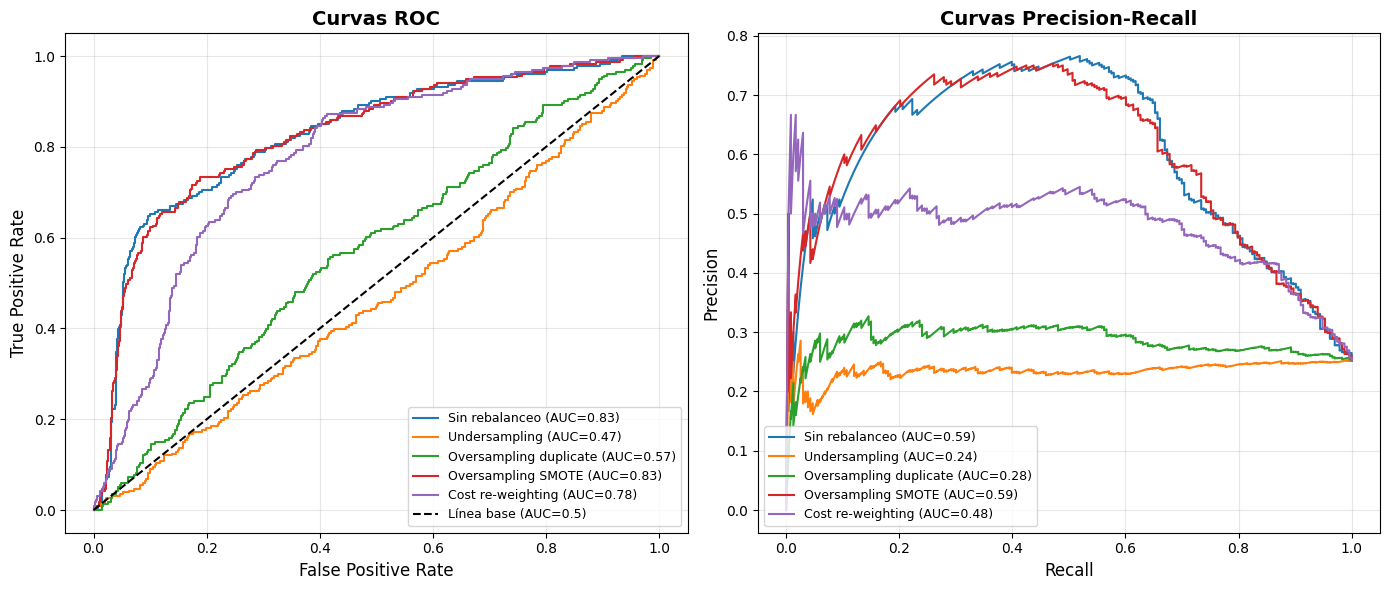

In [ ]:
# Graficar curvas
plt.figure(figsize=(14, 6))

# Curva ROC
plt.subplot(1, 2, 1)
for strategy, m in results.items():
    fpr, tpr, _ = m['roc_curve']
    plt.plot(fpr, tpr, label=f'{strategy} (AUC={m["auc_roc"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Línea base (AUC=0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curvas ROC', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)  # Leyenda dentro, esquina inferior derecha
plt.grid(True, alpha=0.3)

# Curva Precision-Recall
plt.subplot(1, 2, 2)
for strategy, m in results.items():
    precision, recall, _ = m['pr_curve']
    plt.plot(recall, precision, label=f'{strategy} (AUC={m["auc_pr"]:.2f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Curvas Precision-Recall', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=9)  # Leyenda dentro, esquina inferior izquierda
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
best_model = LogisticRegression(lambda_=best_lambda)
df, means, stds = normalize(imbalanced_dev, exclude_cols=["Epthlial", "Mesnchymal", "GeneticMutation", "Diagnosis"])
df = handle_missing_values(imbalanced_dev, strategy='knn', k=5)
best_model.fit( df.drop(columns=["Diagnosis"]), df["Diagnosis"])
save_model(best_model, "best_model.pkl")

In [ ]:
test_set = handle_categorical_features(imbalanced_test)
test_set , _,_ = normalize(test_set, means, stds, exclude_cols=["Epthlial", "Mesnchymal", "GeneticMutation", "Diagnosis"])
test_set = handle_missing_values(test_set, strategy='knn', train_df=df, k=5)


Accuracy: 0.61
Precision: 0.36
Recall: 0.71
F1-Score: 0.48

AUC-PR: 0.23
AUC-ROC: 0.53


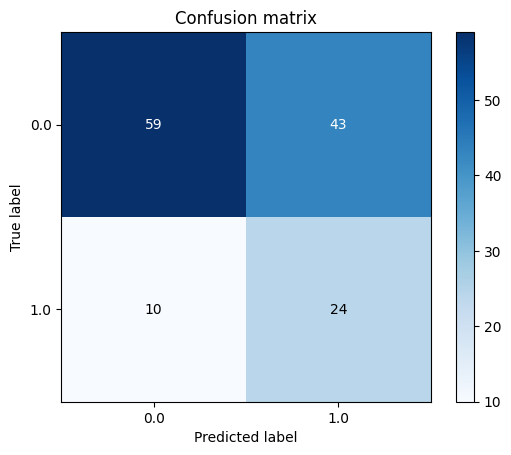

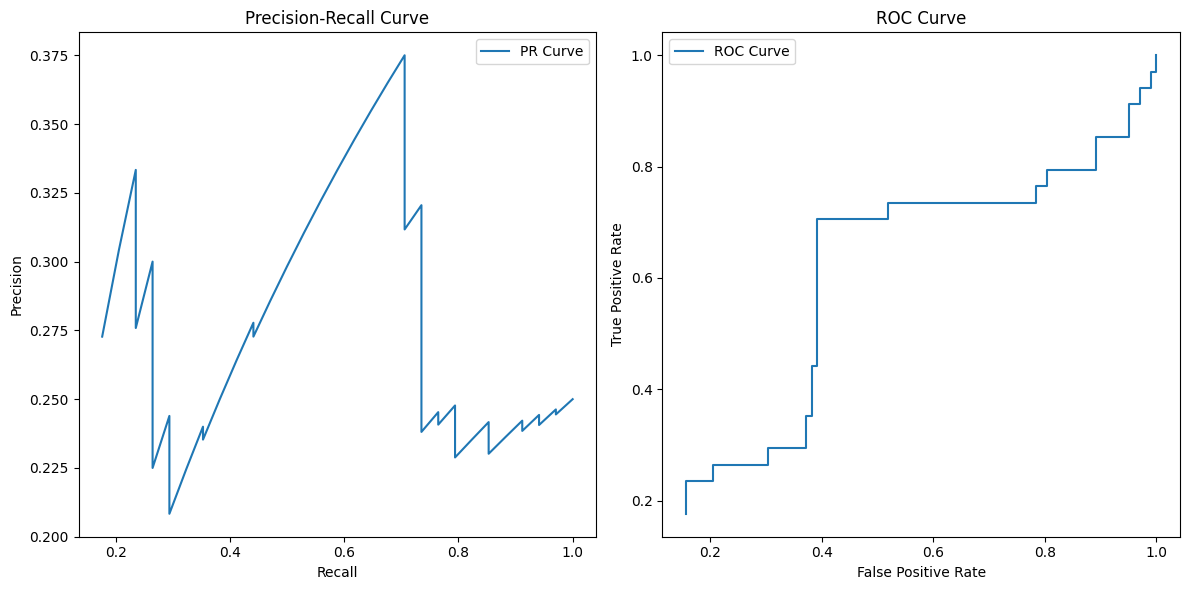

In [ ]:
y_test_pred = best_model.predict(test_set.drop(columns=["Diagnosis"]))
y_test_pred_proba = best_model.predict_proba(test_set.drop(columns=["Diagnosis"]))
display_full_metrics(imbalanced_test["Diagnosis"], y_test_pred, y_test_pred_proba)